# Note to self
For this notebook, use env 'decipherbc-env2'. Keep this env *scib-metrics-only* as you said. numpy 2.4.6 here would conflict with decipher's numpy<2 pin. Don't pip install -e model* into it.

In [2]:
import logging
import pandas as pd
import scanpy as sc
import os
from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib as mpl

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.metrics import silhouette_samples


In [2]:
from scib_metrics.nearest_neighbors import pynndescent
from scib_metrics import ilisi_knn, graph_connectivity, silhouette_batch

/Applications/anaconda3/envs/decipherbc-env2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
sigma = 2.0
seed = 0
rhos = [0.8400, 0.9343, 0.9354, 0.9363]

In [47]:
def draw_plots(adata):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
    sc.pl.embedding(adata, basis="decipher_v", color="batch",
                    show=False, ax=axes[0], size=50, legend_loc="right margin")
    sc.pl.embedding(adata, basis="decipher_v", color="latent_t",
                    show=False, ax=axes[1], size=50)
    # sc.pl.embedding(adata, basis="decipher_v", color="decipher_time",
    #                 show=False, ax=axes[2], size=50)
    plt.tight_layout()
    plt.show()


In [68]:
base_file_path = "/Users/jihyunpark/Documents/Decipher/decipher-bc/Data/Simulated Data/Simulated Adata/shift_sigma_sweep"
sigma = 2.0
seed = 0
adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
adata_mf   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_mf.h5ad')

/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/1779081552.py:4: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/1779081552.py:5: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/1779081552.py:6: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/1779081552.py:7: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_

/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/2938759889.py:4: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/2938759889.py:5: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/2938759889.py:6: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/2938759889.py:7: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_

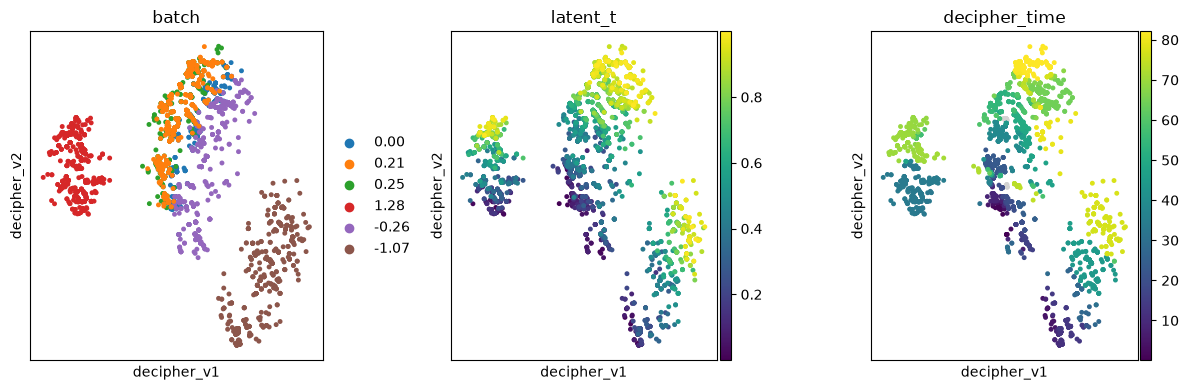

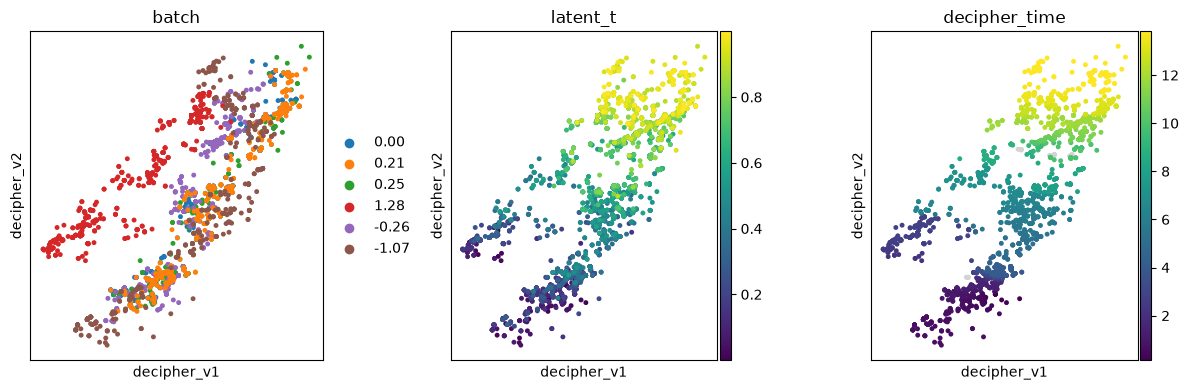

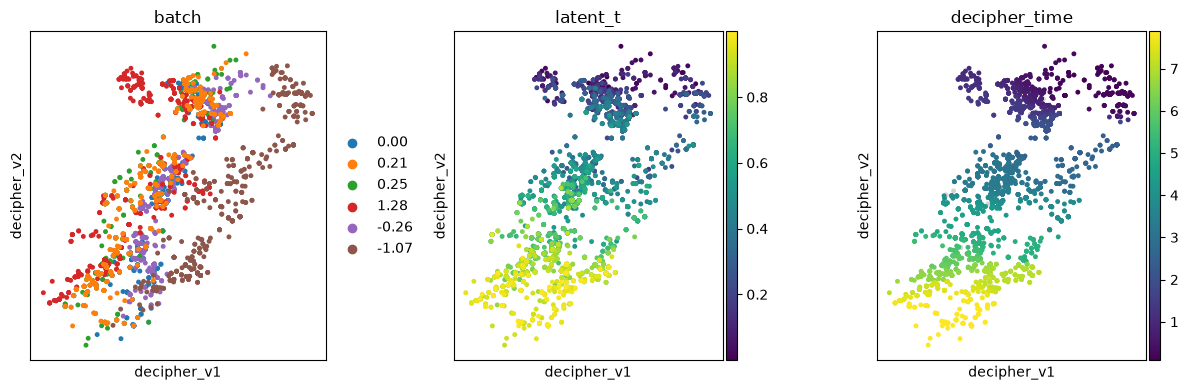

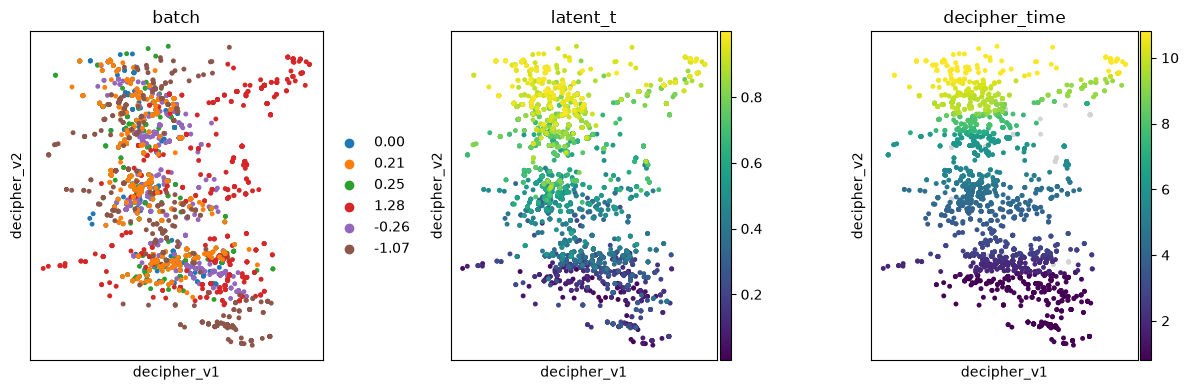

In [ ]:
draw_plots(adata_base)
draw_plots(adata_vz)
draw_plots(adata_vz2)
draw_plots(adata_mf)

In [70]:
from scipy.stats import spearmanr

records = []
for name, ad in [("base", adata_base), ("vz", adata_vz), ("vz2", adata_vz2), ("mf", adata_mf)]:
    m = ad.obs["decipher_time"].notna() & ad.obs["latent_t"].notna()
    rho, _ = spearmanr(ad.obs["decipher_time"][m], ad.obs["latent_t"][m])
    absrho = np.round(abs(rho),2)
    records.append({
        "model": name,
        "|rho|": absrho
    })
    
results = pd.DataFrame(records)
print(results)


  model  |rho|
0  base   0.84
1    vz   0.93
2   vz2   0.94
3    mf   0.94


In [26]:
def viz_pipeline(sigma, seed):
    base_file_path = "/Users/jihyunpark/Documents/Decipher/decipher-bc/Data/Simulated Data/Simulated Adata/shift_sigma_sweep/0724/trained"
    adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
    adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
    adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
    adata_mf   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_mf.h5ad')
    draw_plots(adata_base)
    draw_plots(adata_vz)
    draw_plots(adata_vz2)
    draw_plots(adata_mf)

/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3684430286.py:4: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3684430286.py:5: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3684430286.py:6: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3684430286.py:7: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_

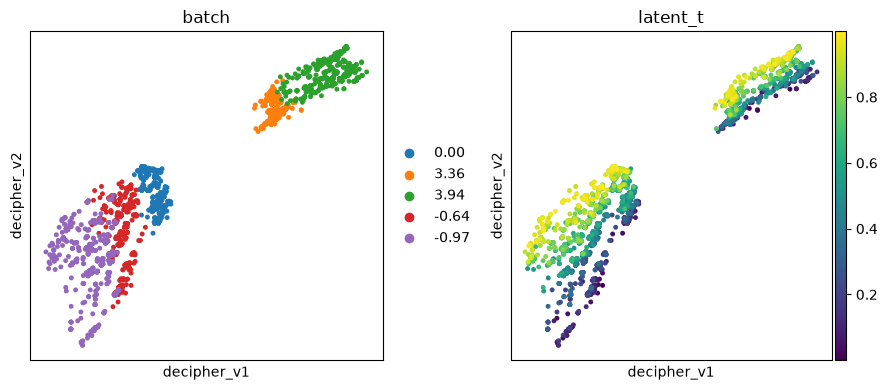

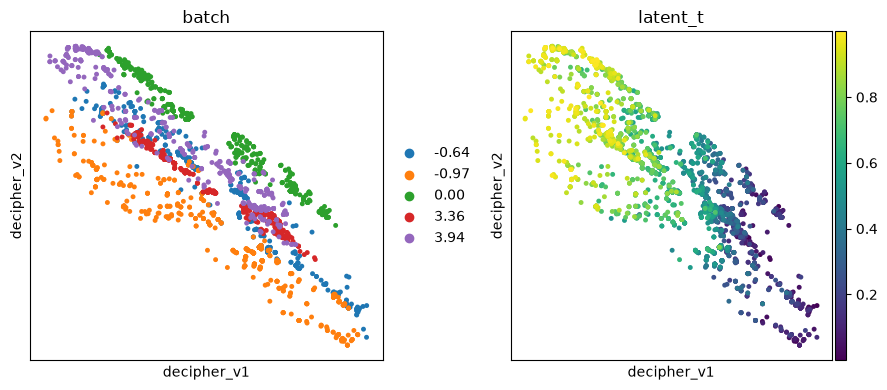

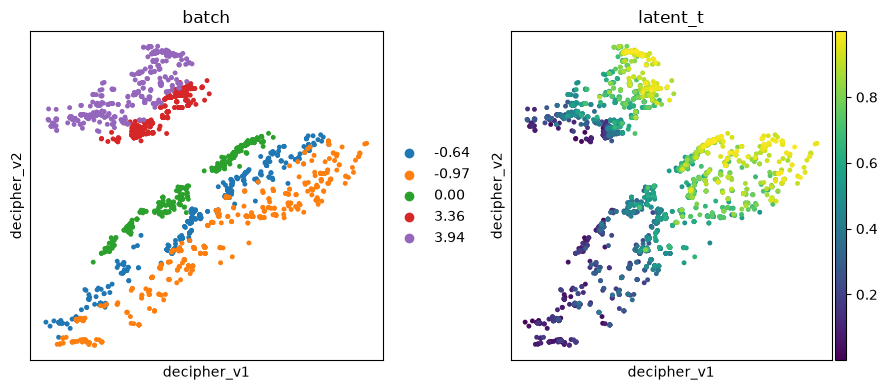

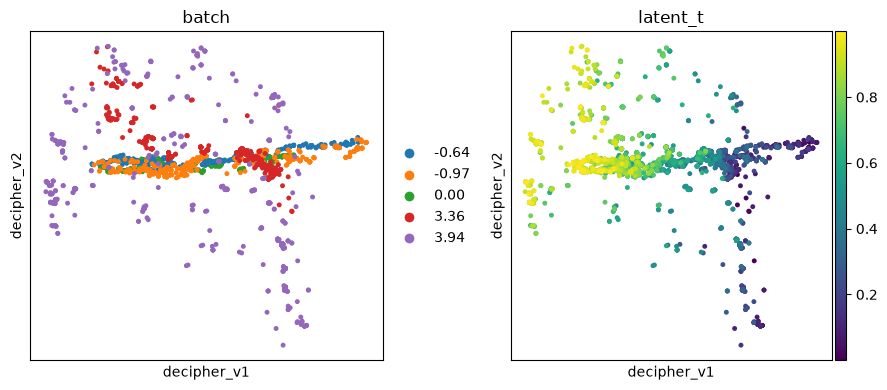

In [46]:
sigma=2.0
seed=0
base_file_path = "/Users/jihyunpark/Documents/Decipher/decipher-bc/Data/Simulated Data/Simulated Adata/shift_sigma_sweep/0724/trained"
adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
adata_mf   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_mf.h5ad')
draw_plots(adata_base)
draw_plots(adata_vz)
draw_plots(adata_vz2)
draw_plots(adata_mf)

/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/957460459.py:4: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/957460459.py:5: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/957460459.py:6: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/957460459.py:7: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_mf  

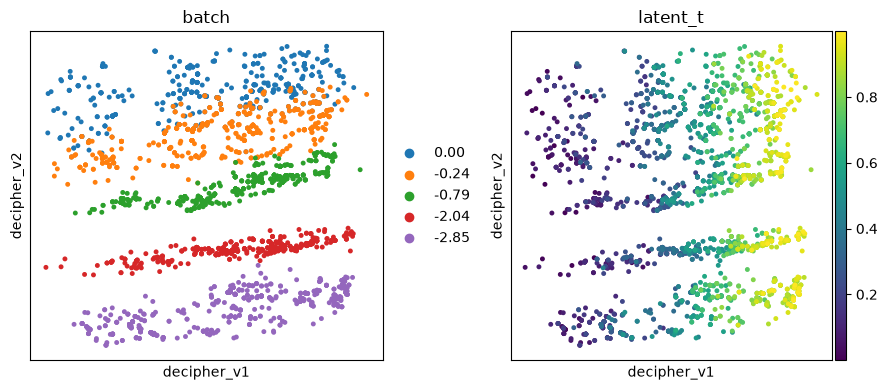

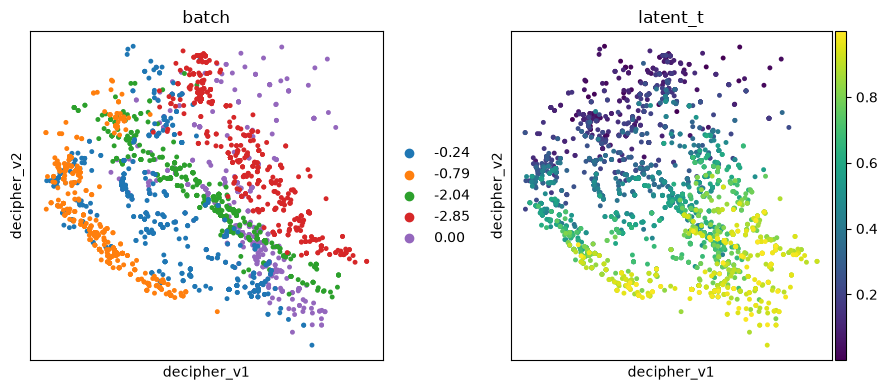

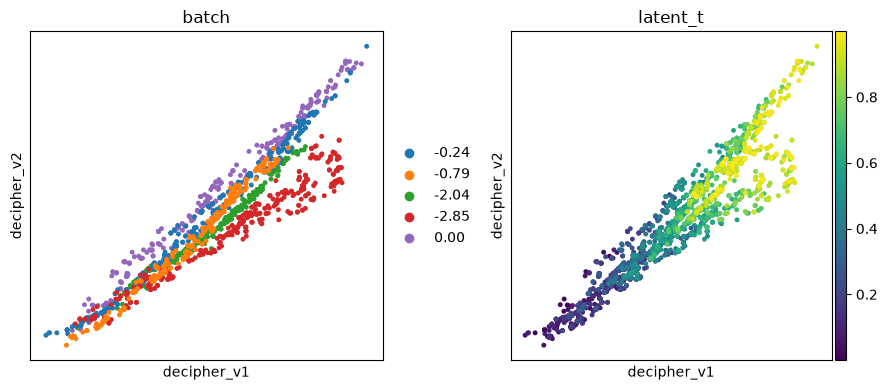

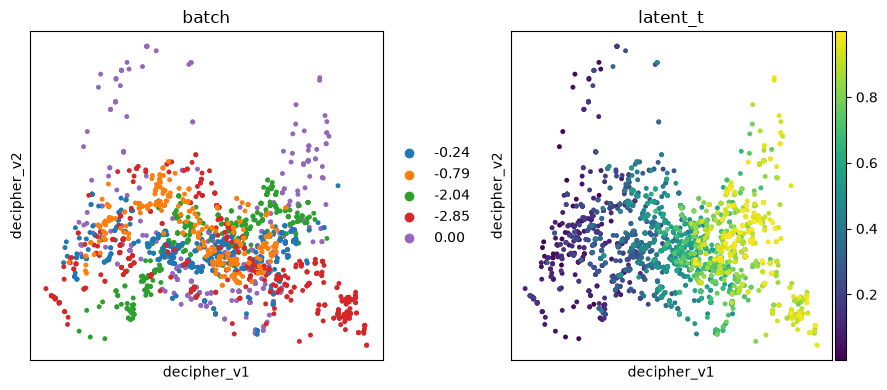

In [48]:
sigma=2.0
seed=3
base_file_path = "/Users/jihyunpark/Documents/Decipher/decipher-bc/Data/Simulated Data/Simulated Adata/shift_sigma_sweep/0724/trained"
adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
adata_mf   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_mf.h5ad')
draw_plots(adata_base)
draw_plots(adata_vz)
draw_plots(adata_vz2)
draw_plots(adata_mf)

In [49]:
def compute_integration_metrics(adata, 
                                v_key="decipher_v", batch_key="batch", t_key="latent_t",
                                n_neighbors=30, n_bins=5):
    from scib_metrics.nearest_neighbors import pynndescent
    from scib_metrics import ilisi_knn, graph_connectivity, silhouette_batch
    import pandas as pd
    import numpy as np
    adata.obs["latent_t_bin"] = pd.qcut(
        adata.obs[t_key], q=n_bins, labels=False
    ).astype("category")
    neigh = pynndescent(adata.obsm[v_key], n_neighbors=n_neighbors)
    batches = adata.obs[batch_key].cat.codes.to_numpy()
    bins    = adata.obs["latent_t_bin"].cat.codes.to_numpy()
    return {
        "ilisi": ilisi_knn(neigh, batches, scale=True),
        "graph_conn": graph_connectivity(neigh, labels=bins),
        "sil_batch": silhouette_batch(adata.obsm[v_key], labels=bins, batch=batches, rescale=True),
    }

In [54]:
seeds = [0, 3]
records = []
for seed in seeds:
    base_file_path = "/Users/jihyunpark/Documents/Decipher/decipher-bc/Data/Simulated Data/Simulated Adata/shift_sigma_sweep/0724/trained"
    adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
    adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
    adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
    adata_mf   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_mf.h5ad')
    for name, ad in [("base", adata_base), ("vz", adata_vz), ("vz2", adata_vz2), ("mf", adata_mf)]:
                m = compute_integration_metrics(ad, n_neighbors=30, n_bins=5)
                records.append({
                    "model": name,
                    "seed": seed,
                    "ilisi": m["ilisi"],
                    "graph_conn": m["graph_conn"],
                    "sil_batch": m["sil_batch"],
                })
                
df = pd.DataFrame(records)
df.round(2)

/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3417686579.py:5: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3417686579.py:6: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3417686579.py:7: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3417686579.py:8: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_

,model,seed,ilisi,graph_conn,sil_batch
0,base,0,0.00,0.27,0.35
1,vz,0,0.00,0.67,0.73
2,vz2,0,0.00,0.29,0.54
3,mf,0,0.01,0.46,0.71
4,base,3,0.00,0.55,0.62
5,vz,3,0.04,0.69,0.72
6,vz2,3,0.03,0.55,0.71
7,mf,3,0.10,0.66,0.73


In [58]:
sigma=2.0
seed=0
base_file_path = "/Users/jihyunpark/Documents/Decipher/decipher-bc/Data/Simulated Data/Simulated Adata/shift_sigma_sweep/0724/trained"
adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
adata_mf   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_mf.h5ad')

records = []
for k in [30, 60]:
    for n_bins in [5, 8]:
        for name, ad in [("base", adata_base), ("vz", adata_vz), ("vz2", adata_vz2), ("mf", adata_mf)]:
            m = compute_integration_metrics(ad, n_neighbors=k, n_bins=n_bins)
            records.append({
                "model": name,
                "n_neighbors": k,
                "n_bins": n_bins,
                "ilisi": m["ilisi"],
                "graph_conn": m["graph_conn"],
                "sil_batch": m["sil_batch"],
            })
            
df = pd.DataFrame(records)
df = df.round(2)
print(df)

/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/1759403623.py:4: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/1759403623.py:5: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/1759403623.py:6: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/1759403623.py:7: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_

   model  n_neighbors  n_bins  ilisi  graph_conn  sil_batch
0   base           30       5   0.00        0.27       0.35
1     vz           30       5   0.00        0.67       0.73
2    vz2           30       5   0.00        0.29       0.54
3     mf           30       5   0.01        0.46       0.71
4   base           30       8   0.00        0.19       0.35
5     vz           30       8   0.00        0.45       0.70
6    vz2           30       8   0.00        0.22       0.53
7     mf           30       8   0.01        0.36       0.71
8   base           60       5   0.00        0.56       0.35
9     vz           60       5   0.02        0.93       0.73
10   vz2           60       5   0.00        0.50       0.54
11    mf           60       5   0.06        0.79       0.71
12  base           60       8   0.00        0.42       0.35
13    vz           60       8   0.02        0.88       0.70
14   vz2           60       8   0.00        0.45       0.53
15    mf           60       8   0.06    

In [ ]:
df.to_csv('metric_params_results.csv')

In [64]:
# Build the config label
df["config"] = "k=" + df["n_neighbors"].astype(str) + " bins=" + df["n_bins"].astype(str)

# Rename metrics for display
df = df.rename(columns={
    "ilisi": "iLISI",
    "graph_conn": "Graph connectivity",
    "sil_batch": "Inverse silhouette",
})

# Pivot to wide format
wide = (df
    .set_index(["model", "config"])[["iLISI", "Graph connectivity", "Inverse silhouette"]]
    .unstack("config"))

# Enforce column ordering: metric groups × config order
config_order = ["k=30 bins=5", "k=30 bins=8", "k=60 bins=5", "k=60 bins=8"]
metric_order = ["iLISI", "Graph connectivity", "Inverse silhouette"]
wide = wide.reindex(columns=pd.MultiIndex.from_product([metric_order, config_order]))

# Enforce row ordering (architectural ladder, not alphabetical)
wide = wide.reindex(["base", "vz", "vz2", "mf"])
print(wide)

            iLISI                                     Graph connectivity  \
      k=30 bins=5 k=30 bins=8 k=60 bins=5 k=60 bins=8        k=30 bins=5   
model                                                                      
base         0.00        0.00        0.00        0.00               0.27   
vz           0.00        0.00        0.02        0.02               0.67   
vz2          0.00        0.00        0.00        0.00               0.29   
mf           0.01        0.01        0.06        0.06               0.46   

                                          Inverse silhouette              \
      k=30 bins=8 k=60 bins=5 k=60 bins=8        k=30 bins=5 k=30 bins=8   
model                                                                      
base         0.19        0.56        0.42               0.35        0.35   
vz           0.45        0.93        0.88               0.73        0.70   
vz2          0.22        0.50        0.45               0.54        0.53   
mf         

In [65]:
wide.to_csv('metric_params_results_wide.csv')

In [67]:
adata_base.obs.shape

(2500, 11)

In [4]:
base_file_path = "/Users/jihyunpark/Documents/Decipher/decipher-bc/Data/Simulated Data/Simulated Adata/shift_sigma_sweep/0724/trained"
sigma=2.0
seed=0
adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
adata_vz = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
adata_vz2 = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
adata_mf = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_mf.h5ad')

/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/2039260548.py:4: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/2039260548.py:5: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/2039260548.py:6: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz2 = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/2039260548.py:7: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_mf 

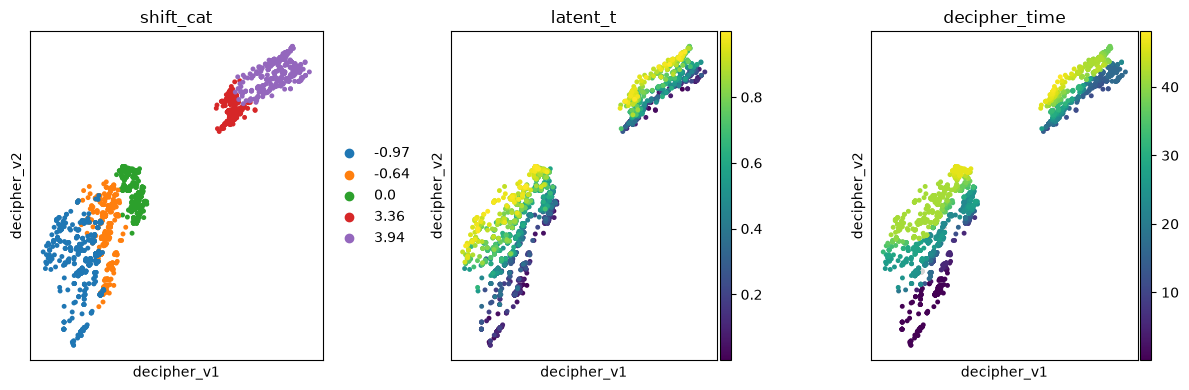

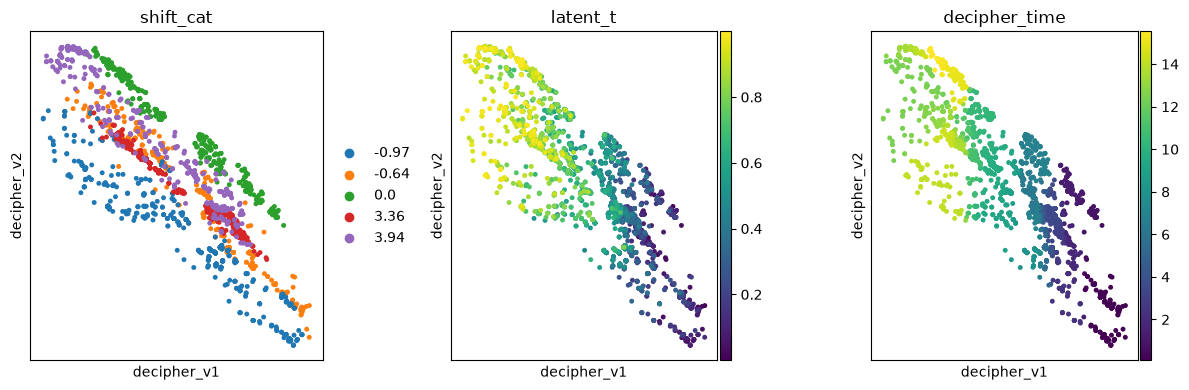

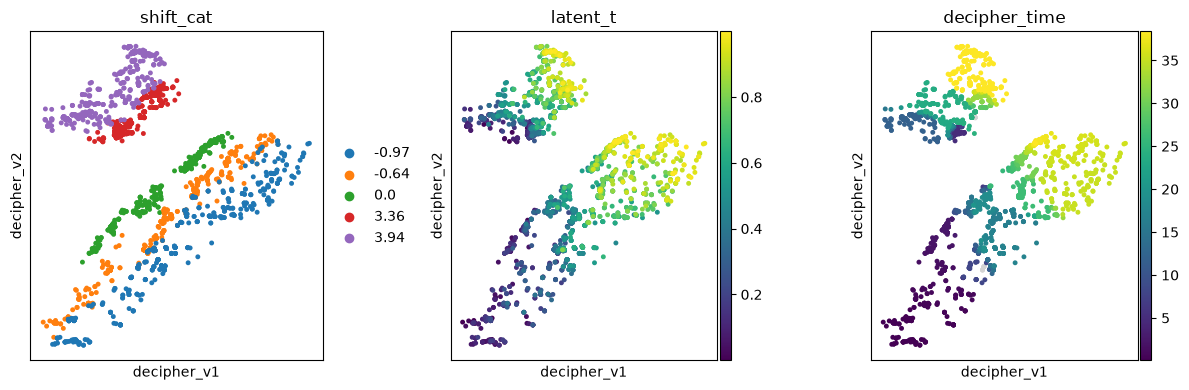

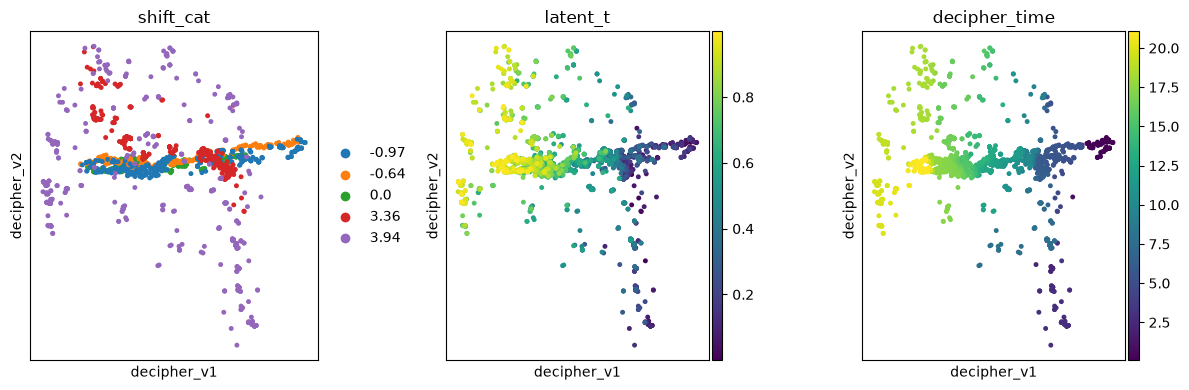

In [5]:
draw_plots(adata_base)
draw_plots(adata_vz)
draw_plots(adata_vz2)
draw_plots(adata_mf)

/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3757573879.py:3: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3757573879.py:4: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3757573879.py:5: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz2 = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3757573879.py:6: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_mf 

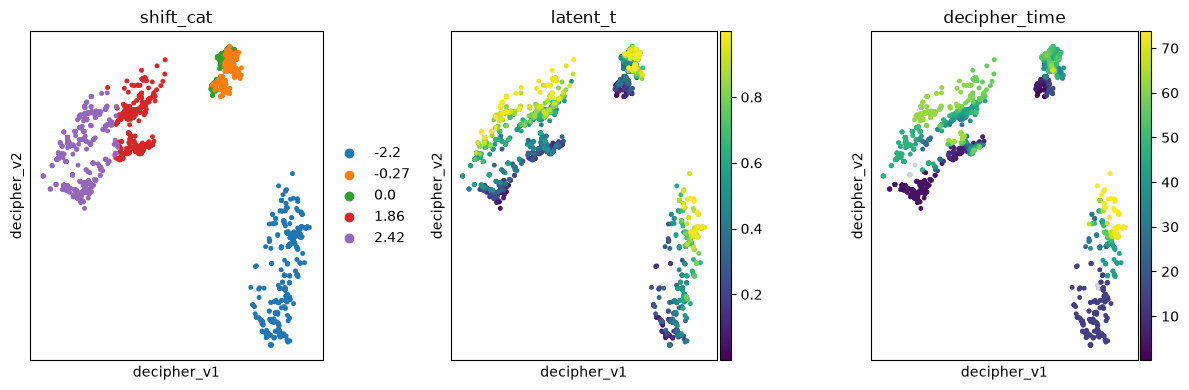

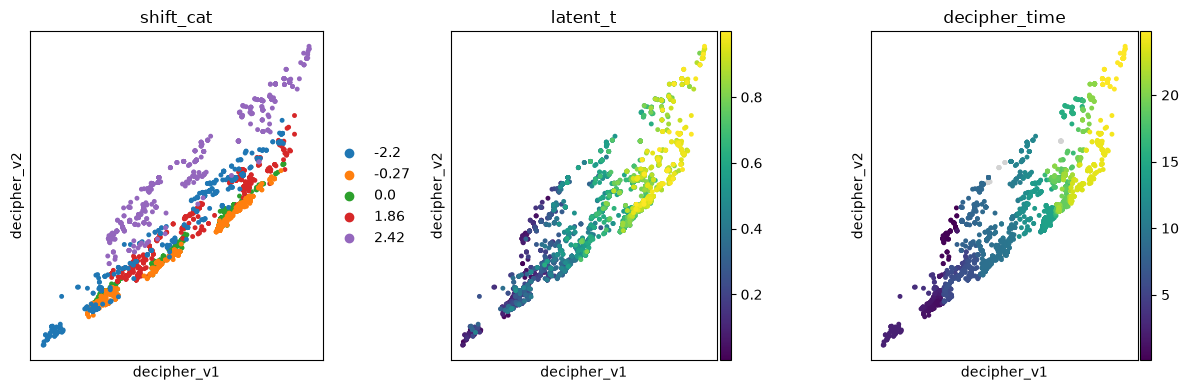

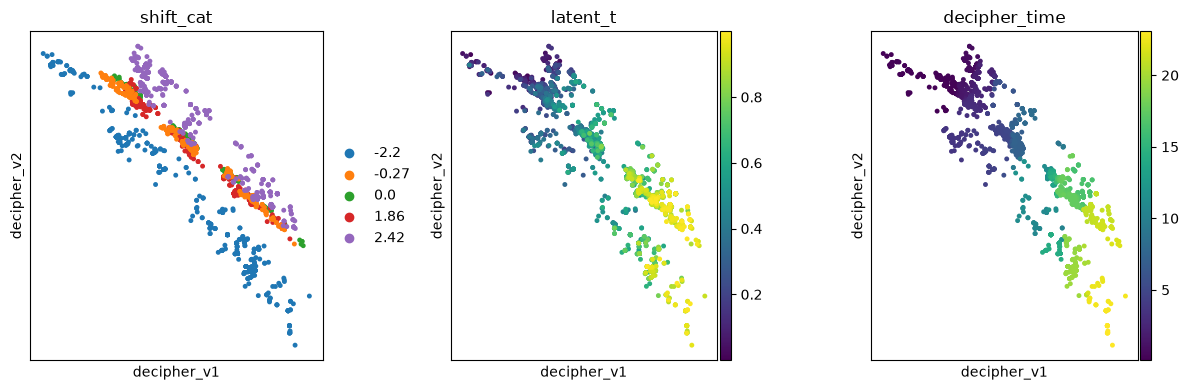

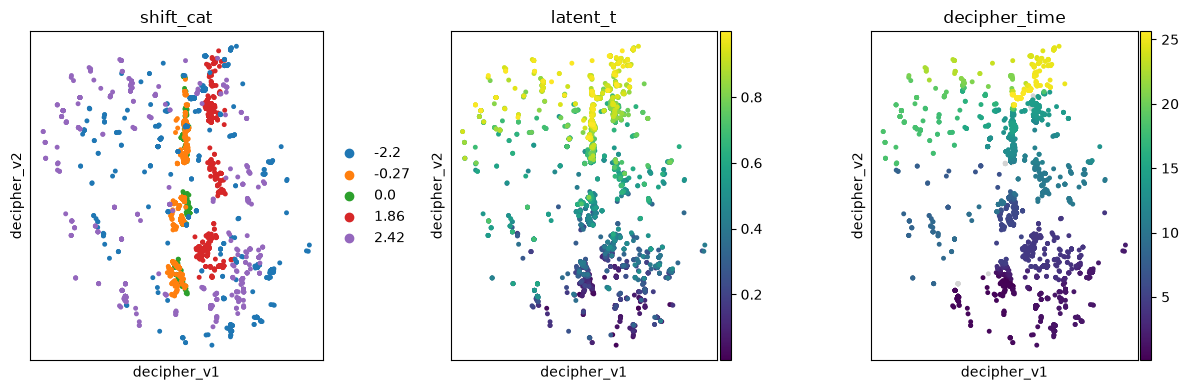

In [6]:
sigma=2.0
seed=1
adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
adata_vz = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
adata_vz2 = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
adata_mf = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_mf.h5ad')
draw_plots(adata_base)
draw_plots(adata_vz)
draw_plots(adata_vz2)
draw_plots(adata_mf)

In [9]:
sigma=2.0
seeds = [0, 1, 2, 3, 4]
records = []

for seed in seeds:
    adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
    adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
    adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
    adata_mf   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_mf.h5ad')

    for model_name, ad in [("base", adata_base), ("vz", adata_vz),
                           ("vz2", adata_vz2), ("mf", adata_mf)]:
        m = compute_integration_metrics(ad, n_neighbors=30, n_bins=5)
        m["seed"] = seed
        m["model"] = model_name
        records.append(m)

results = pd.DataFrame(records)

# Per-model mean and std across seeds
summary = results.groupby("model")[["ilisi", "graph_conn", "sil_batch"]].agg(["mean", "std"])
print(summary)

/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/4186428667.py:6: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/4186428667.py:7: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/4186428667.py:8: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/4186428667.py:9: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_

          ilisi           graph_conn           sil_batch          
           mean       std       mean       std      mean       std
model                                                             
base   0.085524  0.142506    0.33592  0.133880  0.531252  0.155142
mf     0.145056  0.164354    0.41264  0.162330  0.741285  0.049632
vz     0.108322  0.140476    0.53736  0.140169  0.759954  0.051867
vz2    0.111395  0.149427    0.38592  0.101969  0.691104  0.097127


In [10]:
print(results)

           ilisi  graph_conn  sil_batch  seed model
0   2.980232e-08      0.2704   0.353895     0  base
1   2.280116e-03      0.6668   0.725257     0    vz
2   2.980232e-08      0.2944   0.544192     0   vz2
3   1.496735e-02      0.4640   0.705848     0    mf
4   5.960464e-08      0.2572   0.426130     1  base
5   1.536825e-02      0.5256   0.769791     1    vz
6   5.860120e-03      0.4120   0.702137     1   vz2
7   9.238303e-03      0.2200   0.751738     1    mf
8   9.897432e-02      0.2256   0.511211     2  base
9   1.468163e-01      0.3992   0.742135     2    vz
10  1.692926e-01      0.3468   0.680134     2   vz2
11  1.889579e-01      0.3392   0.700115     2    mf
12  5.960464e-08      0.5544   0.620831     3  base
13  3.909796e-02      0.6932   0.717140     3    vz
14  3.316379e-02      0.5512   0.713895     3   vz2
15  1.042236e-01      0.6564   0.726378     3    mf
16  3.286456e-01      0.3720   0.744192     4  base
17  3.380488e-01      0.4020   0.845449     4    vz
18  3.486601

In [11]:
sigma=5.0
seeds = [0, 1, 2, 3, 4]
records = []

for seed in seeds:
    adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
    adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
    adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
    adata_mf   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_mf.h5ad')

    for model_name, ad in [("base", adata_base), ("vz", adata_vz),
                           ("vz2", adata_vz2), ("mf", adata_mf)]:
        m = compute_integration_metrics(ad, n_neighbors=30, n_bins=5)
        m["seed"] = seed
        m["model"] = model_name
        records.append(m)

results = pd.DataFrame(records)

# Per-model mean and std across seeds
summary = results.groupby("model")[["ilisi", "graph_conn", "sil_batch"]].agg(["mean", "std"])
print(summary)

/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/2377127265.py:6: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/2377127265.py:7: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/2377127265.py:8: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/2377127265.py:9: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_

          ilisi           graph_conn           sil_batch          
           mean       std       mean       std      mean       std
model                                                             
base   0.025758  0.057596    0.24368  0.139730  0.347186  0.232185
mf     0.053834  0.108515    0.26424  0.169123  0.641225  0.120475
vz     0.043914  0.079460    0.38720  0.174430  0.534739  0.208873
vz2    0.047897  0.097161    0.27160  0.105477  0.481092  0.212498


In [12]:
sigma=0.5
seeds = [0, 1, 2, 3, 4]
records = []

for seed in seeds:
    adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
    adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
    adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
    adata_mf   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_mf.h5ad')

    for model_name, ad in [("base", adata_base), ("vz", adata_vz),
                           ("vz2", adata_vz2), ("mf", adata_mf)]:
        m = compute_integration_metrics(ad, n_neighbors=30, n_bins=5)
        m["seed"] = seed
        m["model"] = model_name
        records.append(m)

results = pd.DataFrame(records)

# Per-model mean and std across seeds
summary = results.groupby("model")[["ilisi", "graph_conn", "sil_batch"]].agg(["mean", "std"])
print(summary)

/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3600687964.py:6: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3600687964.py:7: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3600687964.py:8: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/3600687964.py:9: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_

          ilisi           graph_conn           sil_batch          
           mean       std       mean       std      mean       std
model                                                             
base   0.263064  0.181235    0.43096  0.109501  0.755423  0.046583
mf     0.313517  0.152547    0.38736  0.085184  0.763950  0.036855
vz     0.294240  0.161647    0.51512  0.096099  0.813991  0.051192
vz2    0.301737  0.153858    0.55264  0.119490  0.803111  0.052316


In [71]:
base_file_path = "/Users/jihyunpark/Documents/Decipher/decipher-bc/Data/Simulated Data/Simulated Adata/shift_sigma_sweep/0724/trained"
sigmas = [0.5, 2.0, 5.0]
seeds = [0, 1, 2, 3, 4]
metric_cols = ["|rho|", "ilisi", "graph_conn", "sil_batch"]

records = []

for sigma in sigmas:
    for seed in seeds:
        adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
        adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
        adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
        adata_mf   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_mf.h5ad')

        for model_name, ad in [("base", adata_base), ("vz", adata_vz),
                               ("vz2", adata_vz2), ("mf", adata_mf)]:
            # Integration metrics
            m = compute_integration_metrics(ad, n_neighbors=30, n_bins=5)

            # |rho| between decipher_time and latent_t
            mask = ad.obs["decipher_time"].notna() & ad.obs["latent_t"].notna()
            if mask.sum() >= 10:
                rho, _ = spearmanr(ad.obs["decipher_time"][mask],
                                   ad.obs["latent_t"][mask])
                m["|rho|"] = abs(rho)
            else:
                m["|rho|"] = np.nan
                print(f"WARN: sigma={sigma} seed={seed} {model_name}: "
                      f"only {mask.sum()} valid cells")
            m["n_valid"] = int(mask.sum())

            m["sigma"] = sigma
            m["seed"] = seed
            m["model"] = model_name
            records.append(m)

results = pd.DataFrame(records)
summary = (
    results
    .groupby(["sigma", "model"])[metric_cols]
    .agg(["mean", "std"])
)
print(summary.round(3))
summary.to_csv(f"{base_file_path}/sweep_metrics_with_rho.csv", index=False)

/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/4198228789.py:10: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_base = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/4198228789.py:11: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz   = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/4198228789.py:12: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  adata_vz2  = sc.read_h5ad(f'{base_file_path}/sigma{sigma}_seed{seed}_decipher_vz2.h5ad')
/var/folders/xs/_0hc9d856q5b46_j5xl3cv6c0000gn/T/ipykernel_31256/4198228789.py:13: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  ad

             |rho|         ilisi        graph_conn        sil_batch       
              mean    std   mean    std       mean    std      mean    std
sigma model                                                               
0.5   base   0.924  0.008  0.263  0.181      0.431  0.110     0.755  0.047
      mf     0.925  0.012  0.314  0.153      0.387  0.085     0.764  0.037
      vz     0.930  0.004  0.294  0.162      0.515  0.096     0.814  0.051
      vz2    0.930  0.007  0.302  0.154      0.553  0.119     0.803  0.052
2.0   base   0.824  0.106  0.086  0.143      0.336  0.134     0.531  0.155
      mf     0.903  0.032  0.145  0.164      0.413  0.162     0.741  0.050
      vz     0.913  0.020  0.108  0.140      0.537  0.140     0.760  0.052
      vz2    0.904  0.021  0.111  0.149      0.386  0.102     0.691  0.097
5.0   base   0.721  0.124  0.026  0.058      0.244  0.140     0.347  0.232
      mf     0.569  0.392  0.054  0.109      0.264  0.169     0.641  0.120
      vz     0.608  0.218

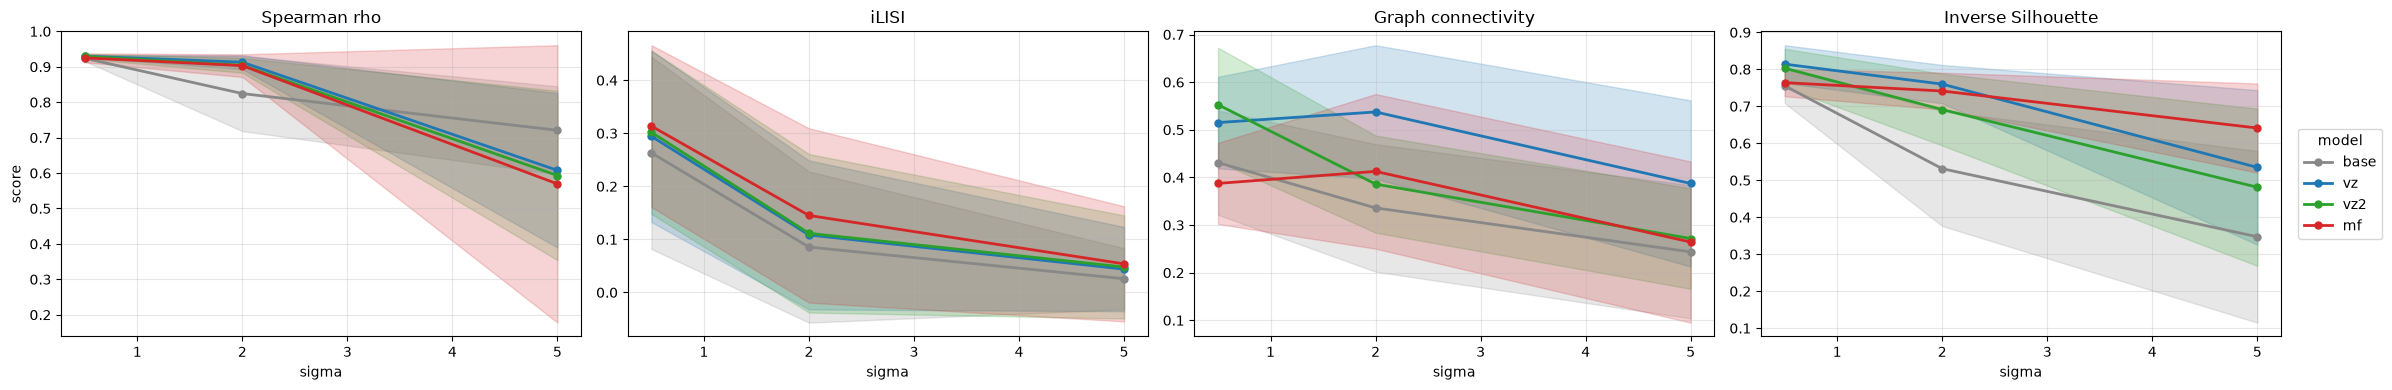

In [72]:

import matplotlib.pyplot as plt

metrics = [
    ("|rho|", "Spearman rho"),
    ("ilisi",      "iLISI"),
    ("graph_conn", "Graph connectivity"),
    ("sil_batch",  "Inverse Silhouette"),
]
models = ["base", "vz", "vz2", "mf"]
model_colors = {"base": "#888888", "vz": "#1f77b4", "vz2": "#2ca02c", "mf": "#d62728"}

fig, axes = plt.subplots(1, 4, figsize=(24, 4), sharex=True)

for ax, (col, title) in zip(axes, metrics):
    for model in models:
        sub = results[results["model"] == model].groupby("sigma")[col].agg(["mean", "std"])
        ax.plot(sub.index, sub["mean"], label=model, color=model_colors[model], linewidth=2, marker="o", markersize=5
                )
        ax.fill_between(sub.index,
                        sub["mean"] - sub["std"],
                        sub["mean"] + sub["std"],
                        color=model_colors[model], alpha=0.2)
    ax.set_title(title)
    ax.set_xlabel("sigma")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("score")
axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), title="model")
plt.tight_layout()
plt.show()

You can inspect the whole shift set before running the sims. Useful for the sanity check I mentioned earlier: np.linalg.norm(shift_matrix, axis=1) gives you the L2 magnitude of each batch's shift, which should be roughly shift_sigma * sqrt(n_z_dims) before normalization.

In [ ]:
n_z_dims = 3
shift_sigma = 0.5
n_batches = 5
seed = 0

mag_rng = np.random.default_rng(seed + 1000)

    # (n_batches, n_z_dims): one shift vector per batch, all drawn together
    # shift distribution is MVN(0, shift_sigma^2 * I) in n_z_dims
shift_matrix = mag_rng.multivariate_normal(
    mean=np.zeros(n_z_dims),
    cov=(shift_sigma ** 2) * np.eye(n_z_dims), # shift components across dimensions are independent. 
    size=n_batches)

l2_mag = np.linalg.norm(shift_matrix, axis=1)
print(np.round(l2_mag, 3))

print(np.round(0.5 * np.sqrt(3), 3))


[0.889 1.171 0.451 1.153 0.867]
0.866


In [6]:
X = mag_rng.multivariate_normal(np.zeros(3), 0.25 * np.eye(3), size=10_000)
norms = np.linalg.norm(X, axis=1)
print(norms.mean(), norms.std())   # should print ~0.798 and ~0.337
print(np.sqrt((norms**2).mean()))  # should print ~0.866 (the σ·√n reference)

0.7930427891693012 0.3328287068353803
0.8600533783127279
